# WFS controls for operation at ALS beamline 5.3.1
walangrizolli@lbl.gov, francisho@lbl.gov, khchan@lbl.gov, awojdyla@lbl.gov

We cleaned up the code, refactoring ophyd classes into nabla.nophyd.
We tried to use the Central tiled server, but somehow we cannot get the data back

We want to: 
+ collect data with various bender settings
+ collect data with various photon energy
+ FrankotChellapize the whole shebang


## Setting up epics/ophyd/bluesky/tiled

In [1]:
from ophyd import EpicsMotor
Obender = EpicsMotor('bl531_esp300:m101_bend_um', name='bender_um')
Obender.low_limit_travel.set(-2000)

# here is the wrapper
#from h01 import mono_energy

Status(obj=EpicsSignal(read_pv='bl531_esp300:m101_bend_um.LLM', name='bender_um_low_limit_travel', parent='bender_um', timestamp=1774652699.0583339, auto_monitor=True, string=False, write_pv='bl531_esp300:m101_bend_um.LLM', limits=False, put_complete=False), done=False, success=False)

In [ ]:
import sys
sys.path.append('/home/bl531/python/nabla/')
from nabla.nophyd import MonoEnergy, BaslerDetector, BCSMotor

In [26]:
mono_energy = MonoEnergy('', name='mono_energy')  # Empty prefix since motor has full PV

In [22]:
Obender.move(-1600)

MoveStatus(done=True, pos=bender_um, elapsed=4.2, success=True, settle_time=0.0)

In [27]:
try:
    basler_camera = BaslerDetector('BL531acA5427:', name='basler_camera')

    # Stage signals — set before each acquisition, restored after
    basler_camera.cam.stage_sigs['image_mode']    = 'Single'
    basler_camera.cam.stage_sigs['num_images']    = 1
    basler_camera.cam.stage_sigs['acquire_time']  = 1.5
    basler_camera.cam.stage_sigs['acquire_period'] = 0.5

    basler_camera.tiff.stage_sigs['file_template'] = '/%s%s_%3.3d.tif'
    # Enable TIFF capture when staged
    basler_camera.tiff.stage_sigs['enable']        = 1
    basler_camera.tiff.stage_sigs['auto_save']     = 'Yes'
    basler_camera.tiff.stage_sigs['file_write_mode'] = 'Single'

    # Only expose the TIFF plugin through read/describe so Tiled picks it up
    basler_camera.read_attrs      = ['tiff']
    basler_camera.tiff.read_attrs = []

    print("Basler camera connected successfully.")

except Exception as e:
    print(f"Error instantiating Basler camera: {e}")
    print("Is the EPICS IOC running? Check PV prefix 'BL531acA5427:'")

Basler camera connected successfully.


In [28]:
import bcs_tcp

# ============================================================
# BCS TCP connection (same as your existing setup)
# ============================================================

ALSU_BOSS_IP = "131.243.80.251"
(host_ip_addr, host_port, host_timeout) = (ALSU_BOSS_IP, 55000, 5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Motor id strings (same as before)
bcs_id_linear = 'Galil x.20 A'
bcs_id_rotary = 'Galil x.20 B'

# Quick sanity check
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print(f'linear stage position is {pos_lin_mm} mm')

# ============================================================
# Instantiate BCSMotor ophyd objects
# ============================================================

bcs_linear_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_linear,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_linear_motor',
)

bcs_rotary_motor = BCSMotor(
    bcs=bcs,
    motor_id=bcs_id_rotary,
    settle_time=0.5,
    tolerance=0.01,
    name='bcs_rotary_motor',
)

# ============================================================
# Quick checks
# ============================================================

print(f'Linear motor position : {bcs_linear_motor.position} mm')
print(f'Rotary motor position : {bcs_rotary_motor.position} deg')
print(bcs_linear_motor)
print(bcs_rotary_motor)

linear stage position is 9.200158 mm
Linear motor position : 9.200158 mm
Rotary motor position : 0.0 deg
BCSMotor(name='bcs_linear_motor', motor_id='Galil x.20 A', position=9.2002 mm)
BCSMotor(name='bcs_rotary_motor', motor_id='Galil x.20 B', position=0.0000 mm)


In [3]:
# The queue server must include the "keep_re" parameter which prevents the RE in this startup script from being overwritten

from bluesky import RunEngine

RE = RunEngine({})

from bluesky.callbacks.best_effort import BestEffortCallback
from bluesky.callbacks.tiled_writer import TiledWriter
from tiled.server import SimpleTiledServer
from tiled.client import from_uri

#load the api key from env var
import os
api_key = os.getenv("TILED_SINGLE_USER_API_KEY")
if not api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

# Initialize the Tiled server and client
tiled_client = from_uri("http://192.168.10.155:8000", api_key=api_key)
tw = TiledWriter(tiled_client, batch_size=1)
## doesnt work yet because the central server is not configured to accept the resource documents with the local file paths. need to patch the resource documents to replace the local path prefix with the central path prefix before sending to central tiled server.

central_tiled_api_key = os.getenv("CENTRAL_API_KEY")
if not central_tiled_api_key:
    raise ValueError("TILED_SINGLE_USER_API_KEY environment variable is not set.")

central_tiled_client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=central_tiled_api_key)


LOCAL_PATH_PREFIX = "mnt/data531"
CENTRAL_PATH_PREFIX = "/global/beegfs/beamlines/bl531/raw"

def patch_ride_filenames(doc: dict):
    """
    a TiledWriter will be sending documents to the central Tiled server.
    For resource documents, we want to patch resource_path;
    Add CENTRAL_PATH_PREFIX in place of LOCAL_PATH_PREFIX as the root key
    Strip LOCAL_PATH_PREFIX from the beginning of resource_path, if it exists
    :param doc_name: Description
    :type doc_name: str
    :param doc: Description
    :type doc: dict
    """    
    resource_path = doc.get("resource_path", "")
    if resource_path.startswith(LOCAL_PATH_PREFIX):
        # Strip LOCAL_PATH_PREFIX and prepend CENTRAL_PATH_PREFIX
        relative_path = resource_path[len(LOCAL_PATH_PREFIX):].lstrip("/")
        new_resource_path = os.path.join(CENTRAL_PATH_PREFIX, relative_path)
        doc["resource_path"] = new_resource_path
        #print(f"Patched resource_path: {resource_path} -> {new_resource_path}")
    return doc

central_tiled_writer = TiledWriter(central_tiled_client, batch_size=1, patches={"resource": patch_ride_filenames})
# uncomment this to connect to central tiled server
RE.subscribe(central_tiled_writer)

RE.subscribe(tw)

bec = BestEffortCallback()

bec.disable_plots()

# Send all metadata/data captured to the BestEffortCallback.
RE.subscribe(bec)

# add 'baseline' stream with start/stop position of ophyd devices passed into 'sd'
from bluesky.preprocessors import SupplementalData
sd = SupplementalData()
RE.preprocessors.append(sd)
if sd:
    sd.baseline = [mono_energy, Obender, bcs_linear_motor] #for now just adding these two. add more as needed.


NameError: name 'mono_energy' is not defined

In [12]:
from bluesky.plans import scan

RE(scan([basler_camera], Obender, -1361, -1361, 1))



Transient Scan ID: 1     Time: 2026-03-27 12:07:39
Persistent Unique Scan ID: 'c63e8f85-8c6b-4ad8-a186-ff982f11377d'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1000.01778                    |
|               bcs_linear_motor | 12.900124                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+------------+
|   seq_num |       time |  bender_um |
+-----------+------------+------------+
|         1 | 12:07:50.5 | -1360.99230 |
+-----------+------------+------------+
generator scan ['c63e8f85'] (scan num: 1)
End-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728   

('c63e8f85-8c6b-4ad8-a186-ff982f11377d',)

In [13]:
uid = 'c63e8f85-8c6b-4ad8-a186-ff982f11377d'
#uid = '8b8ebfcf-125d-46e3-9550-539a9086f067'
# db = central_tiled_client[uid]
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
bends = db['baseline']['bender_um'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

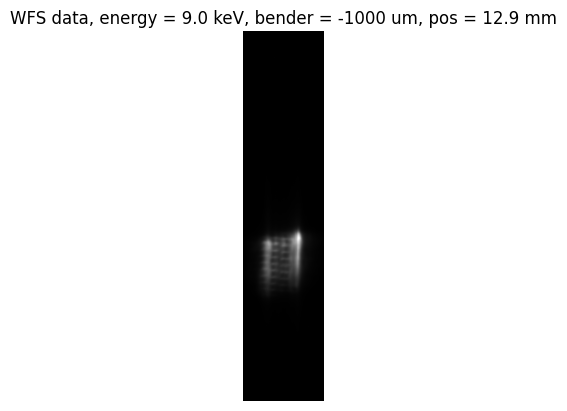

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(images[0], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bender_um[0], wfs_chip_pos_mm[0]))
plt.axis('off')
plt.show()

## Bender scan at position 13
We think we're on row 5 with 7 um shearing grating

In [18]:
from bluesky.plans import scan
# RE(scan([basler_camera], Obender, -1361, -1361, 1))
RE(scan([basler_camera], Obender, -2000, 0, 16))

('bcd61661-8218-4b10-ac2b-e66439c072bc',)

In [114]:
#uid = _
uid = '2ff913c8-3205-470a-8eed-be37c5fa3bc7'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
bends_um = db['primary']['bender_um'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

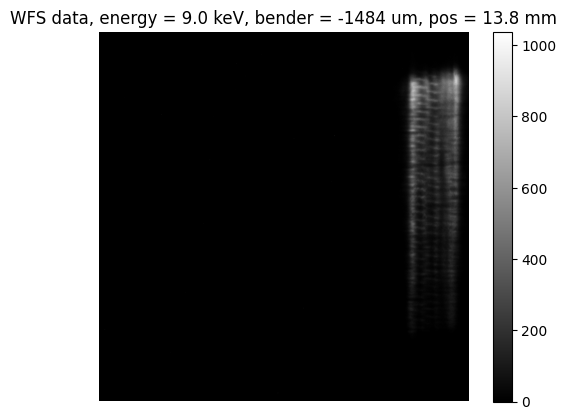

In [89]:
#%matplotlib qt5
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(images[0], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bender_um[0], wfs_chip_pos_mm[0]))
plt.colorbar()
plt.axis('off')
plt.show()


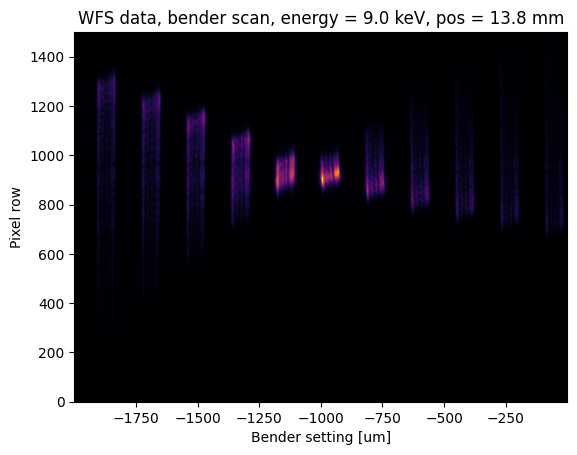

In [119]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])

plt.imshow(stacked_image, cmap='inferno',extent=(bends_um[0], bends_um[-1], 0, stacked_image.shape[0]), origin='upper')
plt.title('Horizontally Stacked Images')
plt.title('WFS data, bender scan, energy = %1.1f keV, pos = %.1f mm' % (E_eV[0]*1e-3, wfs_chip_pos_mm[0]))
plt.xlabel('Bender setting [um]')
plt.ylabel('Pixel row')
plt.show()

## Energy scan 

In [93]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 8000, 9000, 11))



Transient Scan ID: 3     Time: 2026-03-20 14:34:23
Persistent Unique Scan ID: 'eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:34:41.5 |              8000.184 |                20.7550 |
|         2 | 14:34:45.3 |              8099.982 |                20.5750 |
|         3 | 14

('eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a',)

In [121]:
uid = 'eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

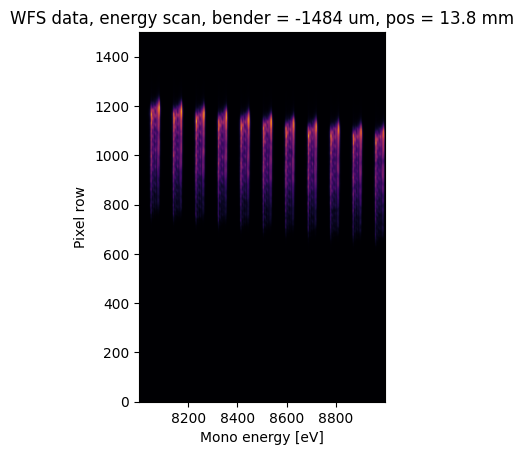

In [ ]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [107]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 7000, 10000, 21))



Transient Scan ID: 4     Time: 2026-03-20 14:41:11
Persistent Unique Scan ID: '9f354b67-6a48-43f7-b3f8-72985e90ea21'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:41:50.9 |              6999.820 |                22.8540 |
|         2 | 14:41:56.4 |              7149.963 |                22.5000 |
|         3 | 14

('9f354b67-6a48-43f7-b3f8-72985e90ea21',)

In [123]:
uid = '9f354b67-6a48-43f7-b3f8-72985e90ea21'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

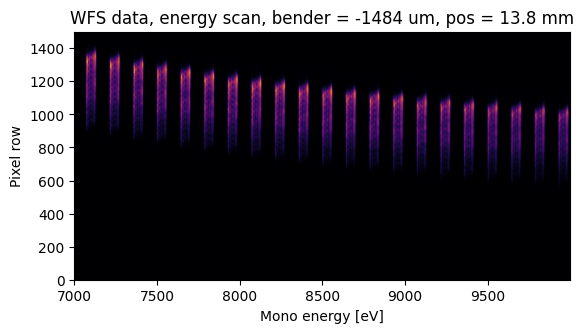

In [124]:
# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [125]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 5000, 11000, 61))



Transient Scan ID: 5     Time: 2026-03-20 14:55:35
Persistent Unique Scan ID: 'acfd18bf-3ffe-4fa0-a381-2be8e82ca207'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 9999.769788152656              |
|         mono_energy_mono_angle | 17.85                          |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:57:59.7 |              4999.987 |                29.7410 |
|         2 | 14:58:15.7 |              5100.013 |                29.2580 |
|         3 | 14

('acfd18bf-3ffe-4fa0-a381-2be8e82ca207',)

In [126]:
uid = 'acfd18bf-3ffe-4fa0-a381-2be8e82ca207'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

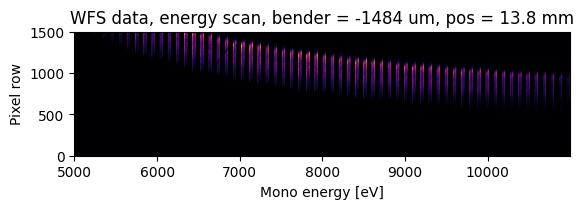

In [127]:
# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [ ]:
from bluesky.plans import grid_scan
#Obender.move(-1484)
RE(grid_scan([basler_camera], mono_energy, 7000, 10000, 7, Obender, -2000, -1000,6, snake_axes=False))  



Transient Scan ID: 7     Time: 2026-03-20 16:45:47
Persistent Unique Scan ID: '2cb2ab5e-8acc-4a66-abec-63ebab791958'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1500.01713                    |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |  bender_um |
+-----------+------------+-----------------------+------------------------+------------+
|         1 | 16:46:27.2 |              6999.820 |                22.8540 | -1999.98786 |
|         2 | 16:46:33.3 |             

('2cb2ab5e-8acc-4a66-abec-63ebab791958',)

CA.Client.Exception...............................................
    Context: "192.168.10.124:41915"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 09:30:37.128617139
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:35637"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 14:39:55.919552227
..................................................................


## Collecting a signle image to develop the analysis and extend it

In [39]:
# count
from bluesky.plans import count
basler_camera.cam.stage_sigs['acquire_time']  = 0.5
uid = RE(count([basler_camera], num=1))



Transient Scan ID: 3     Time: 2026-03-27 14:59:04
Persistent Unique Scan ID: '767b9aeb-460d-4d36-9374-8b8b204d38f7'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755                         |
|                      bender_um | -1599.98997                    |
|               bcs_linear_motor | 9.200158                       |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 14:59:07.6 |
+-----------+------------+
generator count ['767b9aeb'] (scan num: 3)
End-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755           

In [5]:
import numpy as np
uid =  '767b9aeb-460d-4d36-9374-8b8b204d38f7'
db = tiled_client[uid]
image = db['primary']['basler_camera_image'].read()
bends = db['baseline']['bender_um'].read()
mono_energy_eV = db['baseline']['mono_energy_energy_eV'].read()
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()


img_np = np.array(image[0])

In [6]:
import matplotlib.pyplot as plt
plt.imshow(img_np[1500:3000,100:600], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[0]*1e-3, bends[0], wfs_chip_pos_mm[0]))       
plt.colorbar()
plt.show()


In [7]:
import matplotlib.pyplot as plt
plt.imshow(img_np[1500:3000,450:451], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[0]*1e-3, bends[0], wfs_chip_pos_mm[0]))       
plt.colorbar()
plt.show()

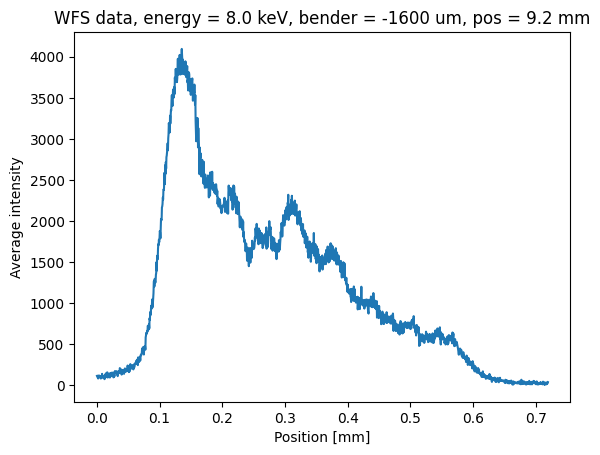

In [24]:
line_avg = img_np[1500:3000,450:451].mean(axis=1)
px_m = 2.40/5/1e6

x_m = np.arange(line_avg.shape[0])*px_m
plt.plot(x_m*1e3, line_avg)
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[0]*1e-3, bends[0], wfs_chip_pos_mm[0]))
plt.xlabel('Position [mm]')
plt.ylabel('Average intensity')
plt.show()


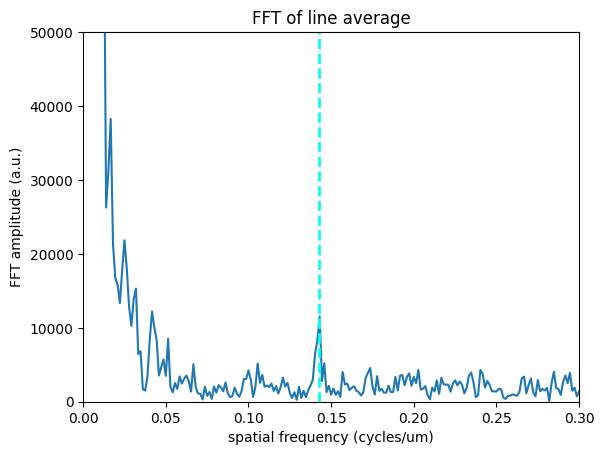

In [23]:
import numpy as np
grating_freq_cpm = 1/(7e-6)  # cycles per meter for 7 um pitch

f_cpm = np.fft.fftshift(np.fft.fftfreq(line_avg.size, d=px_m))
IMG = np.fft.fftshift(np.fft.fft(line_avg))
plt.plot(f_cpm*1e-6, np.abs(IMG))
plt.axvline(grating_freq_cpm * 1e-6, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim(0, 0.30)  # focus on positive frequencies
plt.ylim(0, 50000)
plt.show()  

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

In [25]:
wavelength_m = 1.24e-6 / (mono_energy_eV[0])  # Convert eV to wavelength in meters
grating_pitch_m = 7e-6  # 7 microns in meters   

line = line_avg
line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))

#from scipy.signal import find_peaks

# Transform intensity pattern to frequency domain
I_fft = line_FFT

# Create frequency array
freq = freq_y_cpm
M = len(freq)
df = freq[1]-freq[0]  # Frequency resolution [1/m]

mask = (freq > 0.12e6) & (freq < 0.17e6)

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
# peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
carrier_freq_ideal = grating_freq_cpm
#carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
carrier_idx = np.argmax(I_fft_magnitude*mask)
carrier_freq_measured = freq[carrier_idx]


# Create Gaussian filter centered on +1 order
filter_width = 10.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter



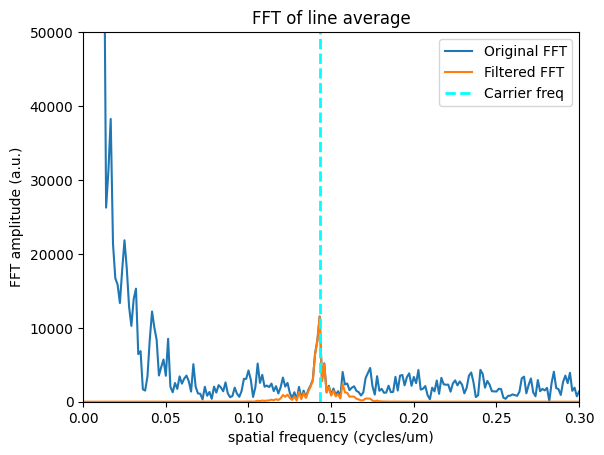

In [26]:
plt.plot(freq*1e-6, np.abs(I_fft), label='Original FFT')
plt.plot(freq*1e-6, np.abs(I_fft_filtered), label='Filtered FFT')
plt.axvline(carrier_freq_measured * 1e-6, color='cyan', linestyle='--', linewidth=2, label='Carrier freq')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim(0, 0.30)  # focus on positive frequencies
plt.ylim(0, 50000)
plt.legend()

In [48]:

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered = phase_unwrapped - phase_unwrapped[M//2]

dy_m = x_m[1] - x_m[0]  # Spatial sampling interval [m]

# Simple cumulative integration with scaling
wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
wavefront_wave = wavefront_reconstructed # Convert to meters




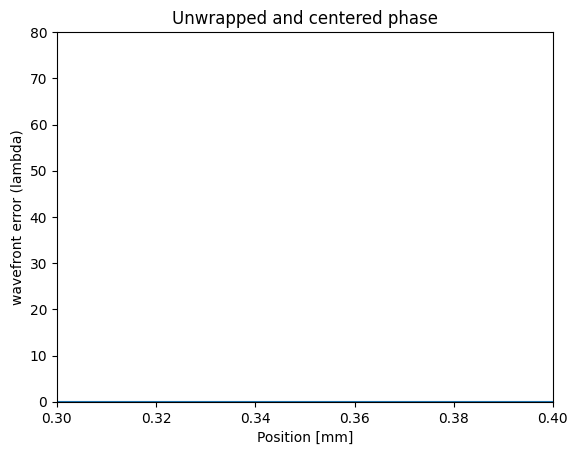

In [55]:
# wavefront error in lambda
plt.plot(x_m*1e3, wavefront_wave)
plt.title('Unwrapped and centered phase')
plt.xlabel('Position [mm]')
plt.ylabel('wavefront error (lambda)')
plt.axis([0.3,0.4,0,80])
plt.show()

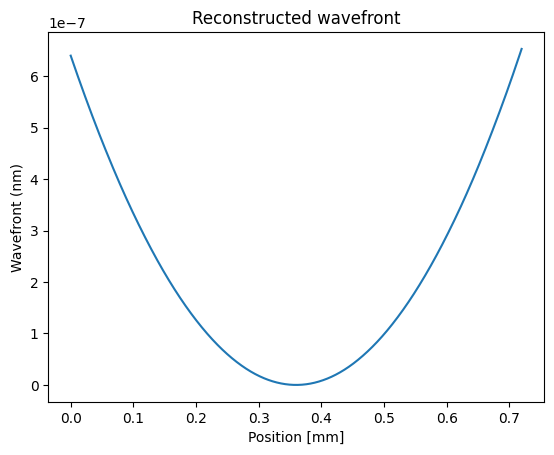

In [ ]:
plt.plot(x_m*1e3, wavefront_reconstructed)
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (nm)')
plt.show()
